In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

In [2]:
# ── PyTorch loaders ────────────────────────────────────────────────────
transform_pt = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_vis = transforms.Compose([transforms.ToTensor()])  # unnormalized for display

train_pt = torchvision.datasets.CIFAR10(root='./data', train=True,  transform=transform_pt,  download=True)
test_pt  = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform_pt,  download=True)
train_vis = torchvision.datasets.CIFAR10(root='./data', train=True,  transform=transform_vis, download=False)
test_vis  = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform_vis, download=False)

train_loader = DataLoader(train_pt, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_pt,  batch_size=128, shuffle=False)

# ── TensorFlow loaders ─────────────────────────────────────────────────
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.cifar10.load_data()
x_all_tf = np.concatenate([x_tr, x_te], axis=0) / 255.0          # (60000,32,32,3)
y_all_tf = np.concatenate([y_tr, y_te], axis=0).flatten()

tf_dataset = (tf.data.Dataset.from_tensor_slices((x_all_tf, y_all_tf))
              .shuffle(2000).batch(128).prefetch(tf.data.AUTOTUNE))

print("PyTorch train:", len(train_pt), "  test:", len(test_pt))
print("TF full data :", x_all_tf.shape)

100%|██████████| 170M/170M [00:05<00:00, 30.4MB/s]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
PyTorch train: 50000   test: 10000
TF full data : (60000, 32, 32, 3)


In [3]:
class CNNFeatureExtractor(nn.Module):
    """3-channel CNN for CIFAR-10 — outputs 256-dim embedding"""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32,  3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 8x8
            nn.Conv2d(64, 128,3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 4x4
            nn.Conv2d(128, 256,3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))                                     # 1x1
        )

    def forward(self, x):
        return self.features(x).view(x.size(0), -1)   # (B, 256)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn_model = CNNFeatureExtractor().to(device)
cnn_model.eval()
print(cnn_model)

CNNFeatureExtractor(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
)


In [4]:
def extract_cnn_features(loader, model):
    feats, lbls = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            feats.append(model(imgs.to(device)).cpu().numpy())
            lbls.extend(labels.numpy())
    return np.vstack(feats), np.array(lbls)

cnn_train_feats, cnn_train_labels = extract_cnn_features(train_loader, cnn_model)
cnn_test_feats,  cnn_test_labels  = extract_cnn_features(test_loader,  cnn_model)
print("CNN train:", cnn_train_feats.shape, "  test:", cnn_test_feats.shape)

CNN train: (50000, 256)   test: (10000, 256)


In [5]:
class ProposedModel(keras.Model):
    """Edge + FFT + Texture Fusion for RGB images (Task 4)"""
    def __init__(self):
        super().__init__()
        self.edge_dense    = layers.Dense(128)
        self.fft_pool      = layers.GlobalAveragePooling2D()
        self.fft_dense     = layers.Dense(128)
        self.texture_dense = layers.Dense(128)

    def call(self, inputs):
        # Edge
        edges = tf.image.sobel_edges(inputs)
        edges = tf.sqrt(tf.reduce_sum(tf.square(edges), axis=-1))
        edges = tf.reduce_mean(edges, axis=[1,2,3])
        edges = tf.expand_dims(edges, -1)
        f_e   = self.edge_dense(edges)                    # (B,128)

        # FFT (on grayscale)
        gray = tf.image.rgb_to_grayscale(inputs)
        fft  = tf.signal.fft2d(tf.cast(gray, tf.complex64))
        fft  = tf.math.abs(fft)
        fft  = self.fft_pool(fft)
        f_f  = self.fft_dense(fft)                        # (B,128)

        # Texture
        mean    = tf.reduce_mean(gray, axis=[1,2])
        var     = tf.math.reduce_variance(gray, axis=[1,2])
        texture = tf.concat([mean, var], axis=-1)
        f_t     = self.texture_dense(texture)             # (B,128)

        f = tf.concat([f_e, f_f, f_t], axis=-1)          # (B,384)
        return tf.nn.l2_normalize(f, axis=1)


class FullModel(keras.Model):
    def __init__(self, num_classes=10):
        super().__init__()
        self.feature_extractor = ProposedModel()
        self.classifier        = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs):
        return self.classifier(self.feature_extractor(inputs))

proposed_full = FullModel(num_classes=10)
proposed_full.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
proposed_full.fit(tf_dataset, epochs=5)
proposed_extractor = proposed_full.feature_extractor

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.2136 - loss: 2.1355
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.2713 - loss: 1.9984
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.2778 - loss: 1.9800
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.2805 - loss: 1.9712
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.2824 - loss: 1.9675


In [6]:
def extract_proposed_features(x_np, y_np, extractor, batch=128):
    ds   = (tf.data.Dataset.from_tensor_slices((x_np, y_np))
            .batch(batch).prefetch(tf.data.AUTOTUNE))
    feats, lbls = [], []
    for imgs, labels in ds:
        feats.append(extractor(imgs).numpy())
        lbls.append(labels.numpy())
    return np.vstack(feats), np.hstack(lbls)

prop_train_feats, prop_train_labels = extract_proposed_features(
    x_all_tf[:50000], y_all_tf[:50000], proposed_extractor)
prop_test_feats,  prop_test_labels  = extract_proposed_features(
    x_all_tf[50000:], y_all_tf[50000:], proposed_extractor)

print("Proposed train:", prop_train_feats.shape, "  test:", prop_test_feats.shape)

Proposed train: (50000, 384)   test: (10000, 384)


In [7]:
def l2_normalize(f):
    return f / (np.linalg.norm(f, axis=1, keepdims=True) + 1e-10)

cnn_train_n  = l2_normalize(cnn_train_feats)
cnn_test_n   = l2_normalize(cnn_test_feats)
prop_train_n = l2_normalize(prop_train_feats)
prop_test_n  = l2_normalize(prop_test_feats)

In [8]:
def fuse_concat(f_cnn, f_prop):
    return l2_normalize(np.concatenate([f_cnn, f_prop], axis=1))

def fuse_weighted(f_cnn, f_prop, lam=0.5):
    d = min(f_cnn.shape[1], f_prop.shape[1])
    return l2_normalize(lam * f_cnn[:, :d] + (1-lam) * f_prop[:, :d])

LAMBDA = 0.6

h_cat_train = fuse_concat(cnn_train_n, prop_train_n)
h_cat_test  = fuse_concat(cnn_test_n,  prop_test_n)

h_ws_train  = fuse_weighted(cnn_train_n, prop_train_n, LAMBDA)
h_ws_test   = fuse_weighted(cnn_test_n,  prop_test_n,  LAMBDA)

print("Concat dim:", h_cat_train.shape[1])
print("WSum   dim:", h_ws_train.shape[1])

Concat dim: 640
WSum   dim: 256


In [9]:
def retrieve(q, db, k=5):
    s = cosine_similarity(q.reshape(1,-1), db)[0]
    return np.argsort(s)[::-1][:k]

def average_precision(ret_lbl, true_lbl):
    sc, correct = 0, 0
    for i, l in enumerate(ret_lbl):
        if l == true_lbl:
            correct += 1
            sc += correct/(i+1)
    return sc / max(correct, 1)

def evaluate_system(test_f, test_l, train_f, train_l, k=5, n=2000):
    prec, rec, APs = [], [], []
    for i in range(min(n, len(test_f))):
        idx  = retrieve(test_f[i], train_f, k)
        rl   = train_l[idx]
        true = test_l[i]
        prec.append(np.sum(rl==true)/k)
        rec.append(np.sum(rl==true)/(np.sum(train_l==true)+1e-8))
        APs.append(average_precision(rl, true))
    return np.mean(prec), np.mean(rec), np.mean(APs)

def robustness_score(test_f, test_l, train_f, train_l, k=5, noise=0.05, n=500):
    scores = []
    for i in range(min(n, len(test_f))):
        nq  = l2_normalize((test_f[i] + np.random.randn(*test_f[i].shape)*noise).reshape(1,-1))[0]
        idx = retrieve(nq, train_f, k)
        scores.append(np.sum(train_l[idx]==test_l[i])/k)
    return np.mean(scores)

In [10]:
K = 5
results = {}

for name, (trf, tef) in [
    ('CNN (Task 3)',         (cnn_train_n,  cnn_test_n)),
    ('Proposed (Task 4)',    (prop_train_n, prop_test_n)),
    ('Hybrid Concat',        (h_cat_train,  h_cat_test)),
    (f'Hybrid WSum λ={LAMBDA}', (h_ws_train, h_ws_test)),
]:
    p, r, m = evaluate_system(tef, cnn_test_labels, trf, cnn_train_labels, k=K)
    rob     = robustness_score(tef, cnn_test_labels, trf, cnn_train_labels, k=K)
    results[name] = (p, r, m, rob)

print(f"\n{'Method':<30} {'Precision':>10} {'Recall':>10} {'mAP':>10} {'Robustness':>12}")
print('-'*75)
for name, (p, r, m, rob) in results.items():
    print(f"{name:<30} {p:>10.4f} {r:>10.4f} {m:>10.4f} {rob:>12.4f}")


Method                          Precision     Recall        mAP   Robustness
---------------------------------------------------------------------------
CNN (Task 3)                       0.3389     0.0003     0.4966       0.1920
Proposed (Task 4)                  0.2041     0.0002     0.3318       0.1872
Hybrid Concat                      0.2849     0.0003     0.4330       0.2244
Hybrid WSum λ=0.6                  0.3144     0.0003     0.4707       0.2124


λ=0.0  mAP=0.2625
λ=0.2  mAP=0.3857
λ=0.4  mAP=0.4221
λ=0.5  mAP=0.4306
λ=0.6  mAP=0.4356
λ=0.8  mAP=0.4634
λ=1.0  mAP=0.4712


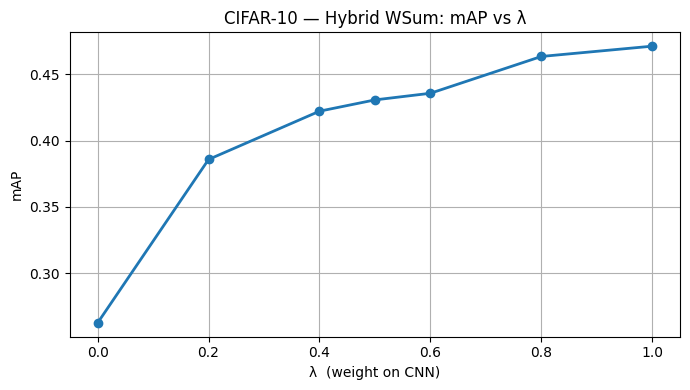

In [11]:
lambdas    = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
map_scores = []

for lam in lambdas:
    ht = fuse_weighted(cnn_train_n, prop_train_n, lam)
    hq = fuse_weighted(cnn_test_n,  prop_test_n,  lam)
    _, _, m = evaluate_system(hq, cnn_test_labels, ht, cnn_train_labels, k=K, n=500)
    map_scores.append(m)
    print(f"λ={lam:.1f}  mAP={m:.4f}")

plt.figure(figsize=(7,4))
plt.plot(lambdas, map_scores, marker='o', linewidth=2)
plt.xlabel('λ  (weight on CNN)'); plt.ylabel('mAP')
plt.title('CIFAR-10 — Hybrid WSum: mAP vs λ')
plt.grid(True); plt.tight_layout(); plt.show()

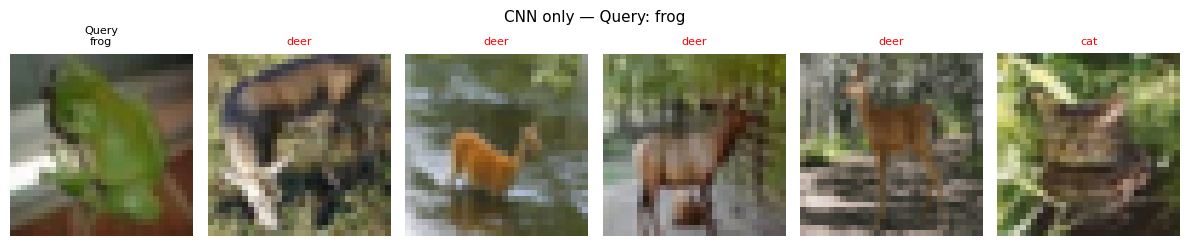

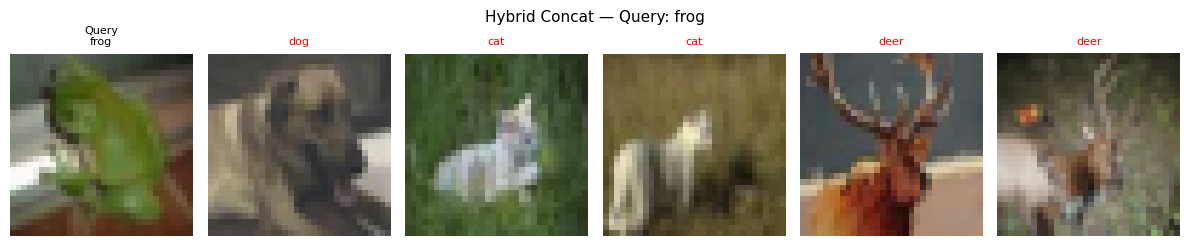

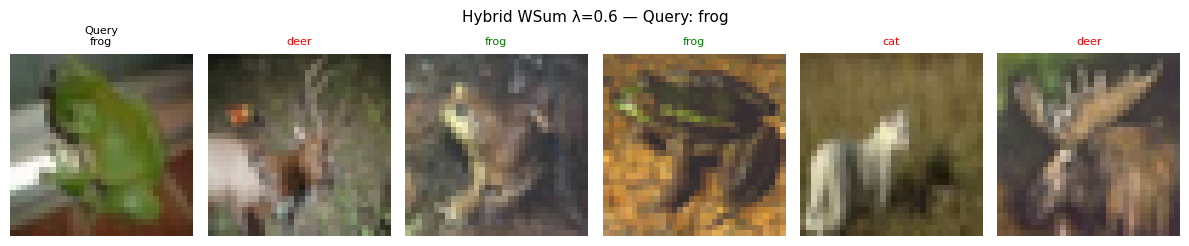

In [12]:
def show_hybrid_results(query_idx, train_db, test_db, train_lbl, test_lbl, k=5, title=''):
    query_feat = test_db[query_idx]
    true_label = test_lbl[query_idx]
    indices    = retrieve(query_feat, train_db, k)

    plt.figure(figsize=(2*(k+1), 2.5))
    plt.suptitle(f'{title} — Query: {CIFAR10_CLASSES[true_label]}', fontsize=11)

    plt.subplot(1, k+1, 1)
    img = test_vis[query_idx][0].permute(1,2,0).numpy()
    plt.imshow(img); plt.title(f'Query\n{CIFAR10_CLASSES[true_label]}', fontsize=8)
    plt.axis('off')

    for i, idx in enumerate(indices):
        plt.subplot(1, k+1, i+2)
        img = train_vis[idx][0].permute(1,2,0).numpy()
        rl  = train_lbl[idx]
        plt.imshow(img)
        plt.title(CIFAR10_CLASSES[rl], fontsize=8,
                  color='green' if rl==true_label else 'red')
        plt.axis('off')

    plt.tight_layout(); plt.show()

QUERY = 7
show_hybrid_results(QUERY, cnn_train_n,  cnn_test_n,  cnn_train_labels, cnn_test_labels,  title='CNN only')
show_hybrid_results(QUERY, h_cat_train,  h_cat_test,  cnn_train_labels, cnn_test_labels,  title='Hybrid Concat')
show_hybrid_results(QUERY, h_ws_train,   h_ws_test,   cnn_train_labels, cnn_test_labels,  title=f'Hybrid WSum λ={LAMBDA}')

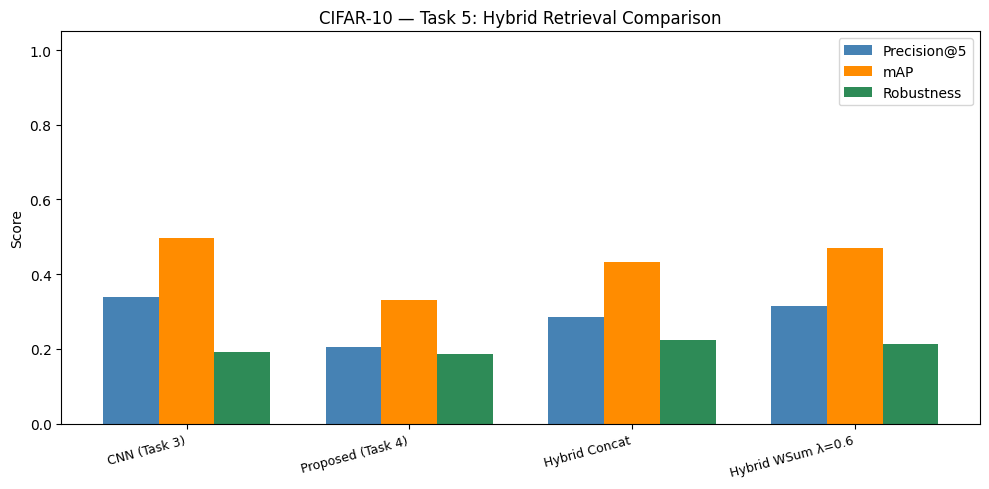

In [13]:
methods   = list(results.keys())
prec_vals = [results[m][0] for m in methods]
map_vals  = [results[m][2] for m in methods]
rob_vals  = [results[m][3] for m in methods]

x = np.arange(len(methods)); w = 0.25
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x-w, prec_vals, w, label='Precision@5', color='steelblue')
ax.bar(x,   map_vals,  w, label='mAP',          color='darkorange')
ax.bar(x+w, rob_vals,  w, label='Robustness',   color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_title('CIFAR-10 — Task 5: Hybrid Retrieval Comparison')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()